In [7]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300
plt.rcParams['hatch.linewidth'] = 0.3
import pandas as pd
import stylia
stylia.set_style("ersilia")
nc = stylia.NamedColors() 
import json
import os

In [8]:
datasets = [["ChEMBL", "chembl4649948"], 
            ["ChEMBL", "chembl4659961"], 
            ["TDC", "ames"], 
            ["TDC", "bbb_martins"], 
            ["TDC", "bioavailability_ma"], 
            ["TDC", "carcinogens_lagunin"], 
            ["TDC", "clintox"], 
            ["TDC", "cyp1a2_veith"], 
            ["TDC", "cyp2c19_veith"], 
            ["TDC", "cyp2c9_substrate_carbonmangels"], 
            ["TDC", "cyp2c9_veith"], 
            ["TDC", "cyp2d6_substrate_carbonmangels"], 
            ["TDC", "cyp2d6_veith"], 
            ["TDC", "cyp3a4_substrate_carbonmangels"], 
            ["TDC", "cyp3a4_veith"], 
            ["TDC", "dili"], 
            ["TDC", "herg"], 
            ["TDC", "hia_hou"], 
            ["TDC", "pgp_broccatelli"], 
            ["TDC", "skin_reaction"],
            ["GARDP", "abaumannii_inh_avg_bin"],
            ["GARDP", "kpneumoniae_atcc_43816_inh_avg_bin"],
            ["GARDP", "kpneumoniae_ecl8_inh_avg_bin"],
            ["GARDP", "kpneumoniae_nctc_13438_inh_avg_bin"]]

PATH_TO_EOSBENCH_RESULTS = os.path.join("../results/eosbench")

In [9]:
# Create results df
files = sorted(os.listdir(PATH_TO_EOSBENCH_RESULTS))
df = pd.concat([pd.read_csv(os.path.join(PATH_TO_EOSBENCH_RESULTS, f)) for f in files], ignore_index=True)
df['source'] = [i.upper() for i in df['source']]

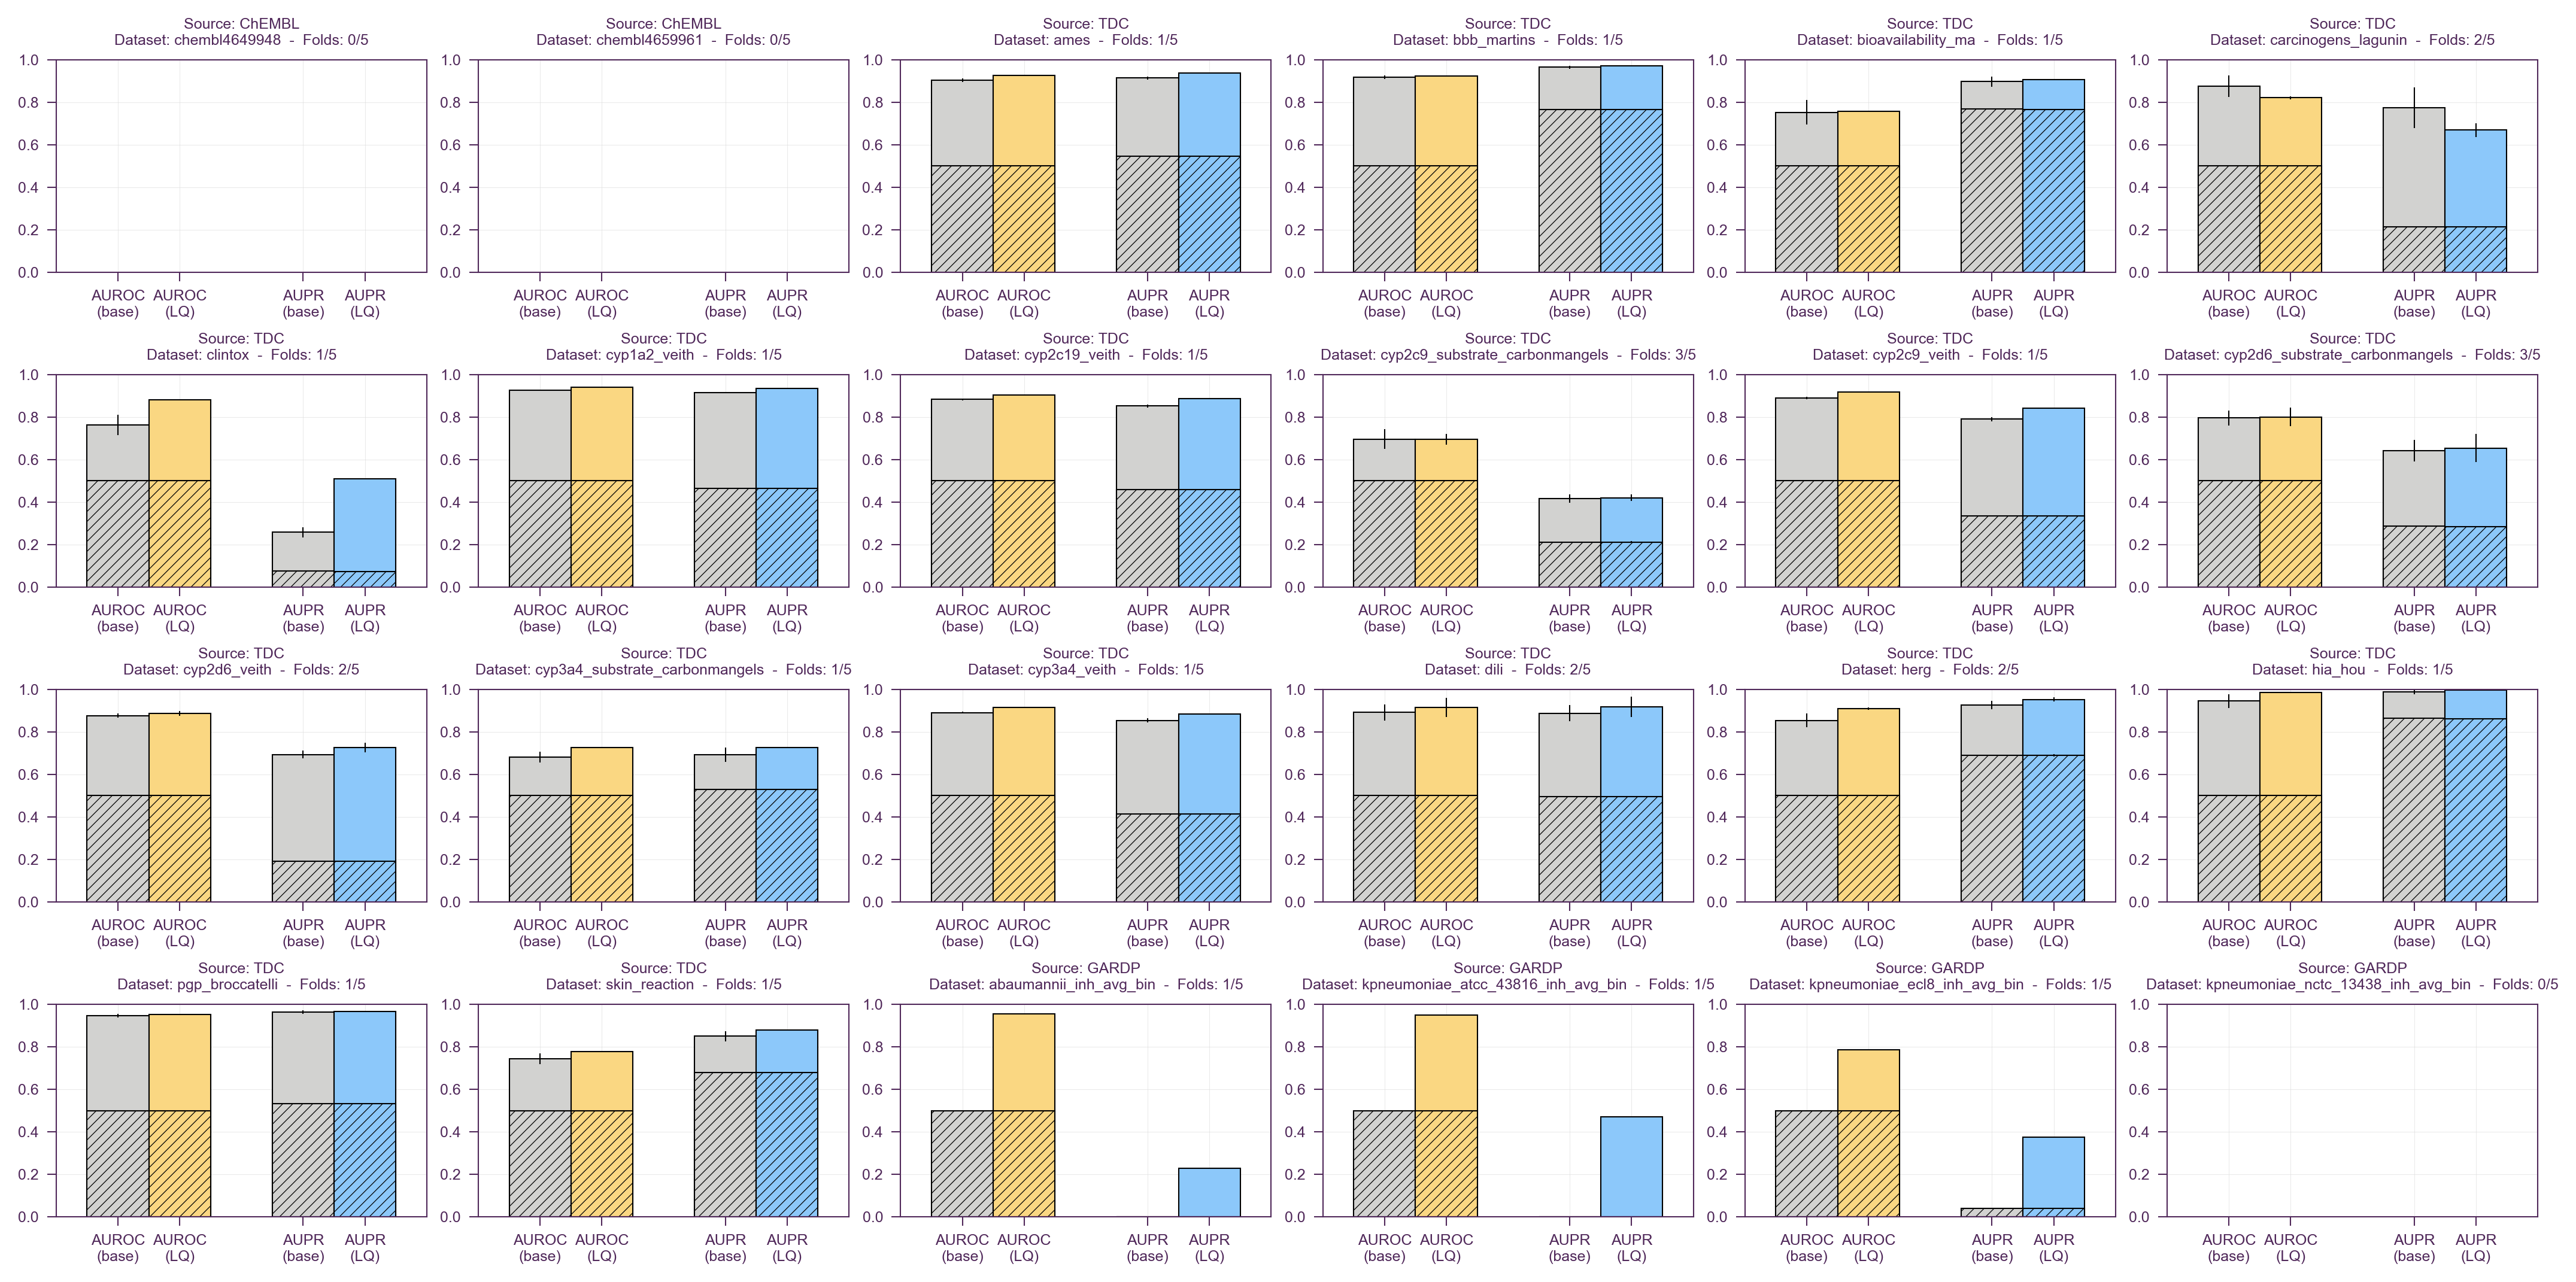

In [10]:
stylia.set_format("print")

fig, axs = stylia.create_figure(4, 6, width=2, height=1)

for source, dataset in datasets:

    # Get values
    df_subset = df[(df['dataset'] == dataset) & (df['source'] == source)]

    # Prepare plot
    ax = axs.next()
    ax.set_title(f"Source: {source}\nDataset: {dataset}  -  Folds: {len(df_subset)}/5")
    ax.set_ylim([0, 1])
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_xlim([0, 6])
    w = 1
    x = [1, 2, 4, 5]
    ax.set_xticks(x)
    ax.set_xticklabels(['AUROC\n(base)', 'AUROC\n(LQ)', 'AUPR\n(base)', 'AUPR\n(LQ)'])

    try:

        auroc_mean = df_subset['auroc'].mean()
        auroc_std = df_subset['auroc'].std()
        aupr_mean = df_subset['aupr'].mean()
        aupr_std = df_subset['aupr'].std()
        auroc_ref_mean = df_subset['auroc_ref_mean'].tolist()[0]
        auroc_ref_std = df_subset['auroc_ref_std'].tolist()[0]
        aupr_ref_mean = df_subset['aupr_ref_mean'].tolist()[0]
        aupr_ref_std = df_subset['aupr_ref_std'].tolist()[0]
        y1 = [auroc_ref_mean, auroc_mean, aupr_ref_mean, aupr_mean]
        y2 = [auroc_ref_std, auroc_std, aupr_ref_std, aupr_std]
        aupr_baseline_mean = df_subset['aupr_baseline'].mean()
        aupr_baseline_std = df_subset['aupr_baseline'].std()
        aupr_baseline_ref = (df_subset['n_pos_train'].tolist()[0] + df_subset['n_pos_test'].tolist()[0]) / (df_subset['n_train'].tolist()[0] + df_subset['n_test'].tolist()[0])
        y_baseline = [0.5, 0.5, aupr_baseline_ref, aupr_baseline_mean]
        y_baseline_std = [0, 0, 0, aupr_baseline_std]
        colors = [nc.gray, nc.yellow, nc.gray, nc.blue]

        # Plot
        for i in range(len(x)):
            ax.bar(x[i], y1[i], color=colors[i], width=w, ec='k', lw=0.5)
            ax.vlines(x[i], y1[i]-y2[i], y1[i]+y2[i], color='k', lw=0.5)
            ax.bar(x[i], y_baseline[i], color=colors[i], width=w, ec='k', lw=0.5, hatch='/'*6)
            ax.vlines(x[i], y_baseline[i]-y_baseline_std[i], y_baseline[i]+y_baseline_std[i], color='k', lw=0.5)

    except:

        pass

plt.tight_layout()
plt.show()

In [11]:
df

,source,dataset,fold,n_folds,n_train,n_test,n_pos_train,n_neg_train,n_pos_test,n_neg_test,auroc,aupr,aupr_baseline,aupr_ratio,auroc_ref_mean,auroc_ref_std,aupr_ref_mean,aupr_ref_std
0,GARDP,abaumannii_inh_avg_bin,0,5,131227,32807,133,131094,30,32777,0.9535,0.2276,0.0009,248.8937,0.0000,0.0000,0.0000,0.0000
1,GARDP,kpneumoniae_atcc_43816_inh_avg_bin,0,5,115485,28872,91,115394,15,28857,0.9490,0.4696,0.0005,903.7902,0.0000,0.0000,0.0000,0.0000
2,GARDP,kpneumoniae_ecl8_inh_avg_bin,0,5,8714,2179,345,8369,85,2094,0.7852,0.3764,0.0390,9.6479,0.0000,0.0000,0.0000,0.0000
3,TDC,ames,0,5,5822,1456,3179,2643,795,661,0.9249,0.9371,0.5460,1.7163,0.9029,0.0079,0.9132,0.0081
4,TDC,bbb_martins,0,5,1631,408,1248,383,312,96,0.9223,0.9713,0.7647,1.2702,0.9168,0.0089,0.9639,0.0064
5,TDC,bioavailability_ma,0,5,512,128,394,118,98,30,0.7571,0.9049,0.7656,1.1819,0.7519,0.0573,0.8965,0.0232
6,TDC,carcinogens_lagunin,0,5,224,56,48,176,12,44,0.8258,0.6454,0.2143,3.0119,0.8746,0.0509,0.7732,0.0956
7,TDC,carcinogens_lagunin,1,5,224,56,48,176,12,44,0.8163,0.6922,0.2143,3.2304,0.8746,0.0509,0.7732,0.0956
8,TDC,clintox,0,5,1182,296,90,1092,22,274,0.8804,0.5095,0.0743,6.8546,0.7627,0.0467,0.2576,0.0252
9,TDC,cyp1a2_veith,0,5,10063,2516,4663,5400,1166,1350,0.9400,0.9343,0.4634,2.0159,0.9256,0.0028,0.9149,0.0040


In [12]:
y2

[0.0, np.float64(nan), 0.0, np.float64(nan)]